# 01 — Análise da imagem: autocorrelação espacial, lags e amostragem

**Executar uma vez por imagem SAR** (altere `DATA`). Substitui o `correlation_2.ipynb` e a chamada de `raster_to_shapefile_sample_by_lags` dos scripts `sample_design_*.R` / `MaxVer_SAR_*.R`.

| Entrada (config) | Saída |
|---|---|
| imagem, ordem das bandas, polígonos de amostra, raster de amostras | `01_lags_amostragem.xlsx`, `amostras.gpkg` (camadas `treino` e `validacao`) |

**Método (Seção 4.3.1.1 da dissertação):**
1. Para cada polígono e polarização, calcula-se a autocorrelação espacial nas direções horizontal e vertical.
2. O lag de cada direção é o primeiro em que a correlação fica abaixo de 0,3.
3. Por classe, toma-se o maior lag entre as polarizações, desconsiderando outliers (critério IQR).
4. Gera-se a amostragem sistemática por esses lags.

Nos scripts R, os lags eram **digitados à mão** a partir da saída do notebook de correlação (`lags <- data.frame(Classe = 1:10, h = ..., v = ...)`). Aqui eles seguem direto para a amostragem, associados às classes pelo **nome**.

> ⚠️ **Duas divergências entre o código original e o texto da dissertação:**
> - **Estimador:** o código divide pelo número de pares (`ESTIMADOR = 'pairs'`), enquanto a Eq. 4.3 divide por N (`'total'`).
> - **Limiar:** o código usa `< 0,3`, enquanto o texto diz `≤ 0,3` (`INCLUSIVO`).
>
> O padrão reproduz o **código**, que é a origem da Tabela 5.1. Numa cena fictícia, o estimador mudou os lags em até 1 pixel.

## Parâmetros

In [1]:
CONFIG = 'exemplo/config_exemplo.json'
DATA = '2008'

ALVO_CORRELACAO = 0.3      # limiar de descorrelação
ESTIMADOR = 'pairs'        # 'pairs' (código original) | 'total' (Eq. 4.3)
INCLUSIVO = False          # False: R < limiar (código) | True: R <= limiar (texto)
TRANSFORMACAO = 'sqrt'     # intensidade -> amplitude antes da autocorrelação (como no original); None se já for amplitude
USAR_IQR = True            # máximo sem outliers
ESTATISTICA_LAG = 'max'    # 'max' (dissertação) | 'median'
LAGS_MANUAIS = None        # ex.: {'AP': (4, 4), 'AC': (4, 4), ...} para impor uma tabela já publicada

PLOTAR_PERFIS = False      # um gráfico por polígono x banda (muitos!)
SALVAR_FIGURAS = False     # True: figuras_01.pdf

## Configuração e arquivos

In [2]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))      # pasta que contém sar_classification

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sar_classification import (autocorrelation as ac, sampling, samples as smp, fitting as fit,
                                separability as sep, models as mdl, validation as val, raster_io as rio,
                                transitions as trn, cmap, trajectory_assessment as ta, plots, reporting)

with open(CONFIG, encoding='utf-8') as f:
    cfg = json.load(f)
RESULTADOS = Path(cfg['raiz_resultados'])
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

img = cfg['imagens'][DATA]
CLASSES = cfg['classes']                         # ordem = códigos 1..K do raster de amostras
BANDAS = img['bandas']                           # ordem REAL das bandas no arquivo (ex.: 2008 = HV, HH)
OUT = RESULTADOS / DATA
OUT.mkdir(parents=True, exist_ok=True)
ARQ_PLANILHA, ARQ_AMOSTRAS = OUT / '01_lags_amostragem.xlsx', OUT / 'amostras.gpkg'
pdf = reporting.open_pdf(OUT / 'figuras_01.pdf') if SALVAR_FIGURAS else None
print(f'Imagem {DATA}: {img["imagem"]}\nBandas: {BANDAS}\nSaídas: {OUT}')

Imagem 2008: /home/claude/projeto/exemplo/dados/SAR_2008.tif
Bandas: ['HV', 'HH']
Saídas: /home/claude/projeto/exemplo/resultados/2008


## 1. Polígonos de amostra

`nomes_poligonos` (config) traduz os nomes da coluna de classe dos polígonos para os nomes de `classes`, caso sejam diferentes.

In [3]:
poligonos = gpd.read_file(img['poligonos_amostras'])
col = img['coluna_classe_poligonos']
poligonos[col] = poligonos[col].astype(str).replace(img.get('nomes_poligonos') or {})
fora = sorted(set(poligonos[col]) - set(CLASSES))
if fora:
    raise ValueError(f'Classes dos polígonos fora de cfg["classes"]: {fora} — ajuste "nomes_poligonos" no config.')
poligonos.groupby(col).size().rename('n_poligonos').to_frame().T

Classe,AC,AP,FD,FP,PL,PS,SE,VS1,VS2,VS3
n_poligonos,3,3,3,3,3,3,3,3,3,3


## 2. Lags por polígono e polarização

In [4]:
lags_poligonos = ac.sample_lags(img['imagem'], poligonos, col, target_correlation=ALVO_CORRELACAO,
                                value_transform=TRANSFORMACAO, estimator=ESTIMADOR, inclusive=INCLUSIVO,
                                plot=PLOTAR_PERFIS)
lags_poligonos['band'] = lags_poligonos['band'].map(lambda b: BANDAS[b - 1])     # 1, 2 -> nome da polarização
lags_poligonos.head()

60 recortes (polígonos x bandas); sem lag definido: h = 0, v = 0.


,polygon,class,band,lag_h,lag_v,n_valid
0,0,AP,HV,3,3,324
1,1,AP,HV,3,3,324
2,2,AP,HV,3,3,324
3,3,AC,HV,2,1,324
4,4,AC,HV,1,2,324


## 3. Lags por classe

In [5]:
resumo_lags = ac.summarize_lags(lags_poligonos, iqr=USAR_IQR)
if LAGS_MANUAIS is None:
    lags = ac.lags_for_sampling(resumo_lags, statistic=ESTATISTICA_LAG)
else:
    lags = pd.DataFrame(LAGS_MANUAIS, index=['h', 'v']).T.astype(int)
    print('Usando LAGS_MANUAIS.')
lags = lags.reindex([c for c in CLASSES if c in lags.index])
display(resumo_lags.round(2))
lags.T

,class,band,n_h,n_v,median_h,median_v,max_h,max_v
0,AC,HH,3,3,3.0,2.0,3.0,3.0
1,AC,HV,3,3,2.0,2.0,3.0,3.0
2,AP,HH,3,3,2.0,3.0,3.0,3.0
3,AP,HV,3,3,3.0,3.0,3.0,3.0
4,FD,HH,3,3,3.0,2.0,3.0,3.0
5,FD,HV,3,3,2.0,3.0,3.0,3.0
6,FP,HH,3,3,2.0,3.0,2.0,3.0
7,FP,HV,3,3,3.0,3.0,3.0,4.0
8,PL,HH,3,3,2.0,2.0,2.0,3.0
9,PL,HV,3,3,2.0,2.0,2.0,3.0


class,AP,AC,FD,FP,PL,PS,SE,VS1,VS2,VS3
h,3,3,3,3,2,3,2,2,3,3
v,3,3,3,4,3,3,4,3,3,3


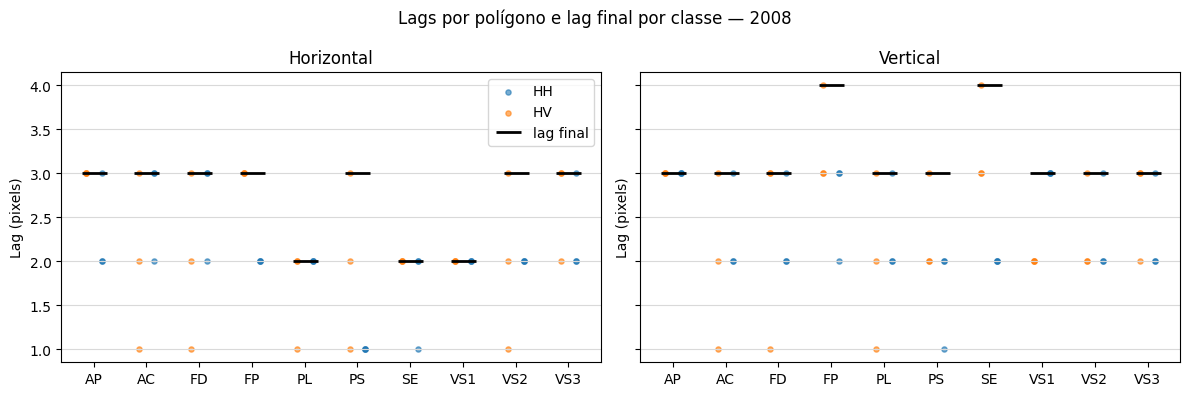

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, d in zip(axes, ['lag_h', 'lag_v']):
    for b, g in lags_poligonos.groupby('band'):
        pos = {c: i for i, c in enumerate(lags.index)}
        x = g['class'].map(pos) + (0.15 if b == BANDAS[1] else -0.15)
        ax.scatter(x, g[d], s=14, alpha=0.6, label=b)
    ax.plot(range(len(lags)), lags[d[-1]], 'k_', ms=18, mew=2, label='lag final')
    ax.set_xticks(range(len(lags)), lags.index); ax.set_title({'lag_h': 'Horizontal', 'lag_v': 'Vertical'}[d])
    ax.set_ylabel('Lag (pixels)'); ax.grid(axis='y', color='0.85')
axes[0].legend()
plt.suptitle(f'Lags por polígono e lag final por classe — {DATA}'); plt.tight_layout()
if pdf: pdf.savefig(fig)
plt.show()

## 4. Amostragem sistemática por lags

Para cada classe, o treino é formado pelos pixels da grade com passo `h × v`. A validação recebe os demais pixels da classe.

> A validação inclui vizinhos imediatos dos pixels de treino, portanto correlacionados com eles. Use-a com essa ressalva.

In [7]:
treino, validacao = sampling.lag_grid_split(img['raster_amostras'], CLASSES, lags)
contagem = pd.DataFrame({'treino': treino['class_name'].value_counts(), 'validacao': validacao['class_name'].value_counts()})
contagem = contagem.reindex(lags.index).fillna(0).astype(int)
contagem['total'] = contagem.sum(axis=1)
contagem['proporcao_treino_%'] = (100 * contagem['treino'] / contagem['total']).round(2)
contagem                                                                    # equivalente à Tabela 5.2

,treino,validacao,total,proporcao_treino_%
class,,,,
AP,48,382,430,11.16
AC,74,604,678,10.91
FD,78,624,702,11.11
FP,48,541,589,8.15
PL,96,465,561,17.11
PS,60,498,558,10.75
SE,70,538,608,11.51
VS1,109,540,649,16.80
VS2,78,605,683,11.42


## 5. Gravação

In [8]:
sampling.save_points(treino, ARQ_AMOSTRAS, layer='treino')
sampling.save_points(validacao, ARQ_AMOSTRAS, layer='validacao')
reporting.save_workbook(ARQ_PLANILHA, {
    'lags_poligonos': lags_poligonos,
    'resumo_por_classe_banda': resumo_lags,
    'lags_finais': lags.reset_index().rename(columns={'index': 'classe', 'class': 'classe'}),
    'amostras': contagem.reset_index().rename(columns={'index': 'classe'}),
    'parametros': pd.DataFrame({'parametro': ['DATA', 'ALVO_CORRELACAO', 'ESTIMADOR', 'INCLUSIVO', 'TRANSFORMACAO',
                                              'USAR_IQR', 'ESTATISTICA_LAG', 'LAGS_MANUAIS'],
                                'valor': [DATA, ALVO_CORRELACAO, ESTIMADOR, INCLUSIVO, TRANSFORMACAO, USAR_IQR,
                                          ESTATISTICA_LAG, str(LAGS_MANUAIS)]})})
if pdf: pdf.close()
print(f'Amostras: {ARQ_AMOSTRAS} (treino: {len(treino)} | validação: {len(validacao)})')

Planilha gravada: /home/claude/projeto/exemplo/resultados/2008/01_lags_amostragem.xlsx (5 abas: lags_poligonos, resumo_por_classe_banda, lags_finais, amostras, parametros)
Amostras: /home/claude/projeto/exemplo/resultados/2008/amostras.gpkg (treino: 731 | validação: 5381)
